# 06 — Temperature sweep (−40 °C … +125 °C)

Created with Grok Build

Passives scale with TCR. Typical $V_{\mathrm{ADJ}}(T)$ follows G05. Envelope WC at each T uses the **25 °C Electrical Characteristics box** at 25 °C and the **over-temperature box** everywhere else.


## Setup — editable BOM and run knobs

This cell is shared by every notebook. It puts `P5V_Regulator/` on `sys.path`
and builds **one** `CircuitParams` object. Change a resistor, capacitor, or
tolerance here and re-run: analytical, SPICE, WC, and MC all follow this object.

**Plot callouts:** each figure cell has an `ann = [dict(...), ...]` list.
Edit `text`, `xy` (data coords of the arrow tip), and `offset=(dx, dy)` in
**points** to nudge a label. Use `xytext=(x, y)` instead of `offset` for data
coordinates. `arrow=False` for a plain label. `ann = []` hides all callouts.

Tolerances are **fractions** (0.01 = 1 %). Figures go to `results/figures/`.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
def _find_project_root() -> Path:
    start = Path.cwd().resolve()
    named = Path("Sections/Electronics/Analog_and_Digital/LT3010_5V_Supply")
    candidates = [start, *start.parents, start / named]
    if start.name == "notebooks":
        candidates.insert(0, start.parent)
    for cand in candidates:
        if (cand / "p5v_design" / "__init__.py").is_file():
            return cand
    return start

ROOT = _find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from p5v_design.params import CircuitParams, ToleranceSpec, format_eng, LdoParams
from p5v_design import analysis, schematic, plots, stability
from p5v_design import plots_wc_mc as pwc
from p5v_design.ldo_model import dropout_v, ignd_a, tj_c, psrr_db, vadj_typical_vs_temp
from dataclasses import replace

# --- EDITABLE BOM ---
# Datasheet TA01, "5V Supply with Shutdown" (LT3010/LT3010-5 Rev. J page 1).
# Fixed 5 V part: SENSE tied to OUT (R1 = 0). No external divider (R2 open).
# Capacitors are the 1 µF parts drawn on that figure. Load is the labeled 50 mA.
# VIN is printed as 5.4 V to 80 V; 12 V is the single-point bias inside that range.
R1 = 0.0             # SENSE shorted to OUT
R2 = 1.0e12          # open — no bottom resistor
CFF = 0.0            # no feedforward capacitor on the fixed part
COUT = 1.0e-6
CIN = 1.0e-6
ESR_OUT = 10e-3      # ceramic assumption, not printed on TA01
ESR_IN = 10e-3
RLOAD = 100.0        # 5 V / 50 mA
R_TOL = 0.01         # 1 %
C_TOL = 0.10         # 10 %
VIN_NOM = 12.0
VIN_MIN = 5.4
VIN_MAX = 80.0
ILOAD_OP = 50e-3
N_MC = 2000
N_SPICE_MC = 40
N_LTSPICE_MC = 40
SKIP_SPICE_WC_MC = False
RUN_LTSPICE_BATCH = True
SPICE_WORKERS = None
LTSPICE_WORKERS = None

p = CircuitParams(
    r1=R1, r2=R2, cff=CFF, cout=COUT, cin=CIN,
    esr_out=ESR_OUT, esr_in=ESR_IN, r_load=RLOAD,
    r_tol=ToleranceSpec(R_TOL), c_tol=ToleranceSpec(C_TOL),
)
p = replace(p, op=replace(p.op, vin_nom=VIN_NOM, vin_min=VIN_MIN, vin_max=VIN_MAX,
                           iload_op=ILOAD_OP, r_load=RLOAD))

FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
print("gain =", p.gain, "  Vout nom =", analysis.vout_dc(p))
print("SPICE_WORKERS =", SPICE_WORKERS, "  N_MC =", N_MC)


gain = 1.0   Vout nom = 5.0
SPICE_WORKERS = None   N_MC = 2000


## What this cell plots

Seven figures from one analytical sweep `sweep_analytical(p)` on the MP grid
(−40 °C … +125 °C, 20 °C steps plus the usual corners −40 / 0 / 25 / 85 / 125).

| Figure | File | What it is |
|--------|------|------------|
| $V_{\mathrm{OUT}}$ vs $T$ | `06_vout_vs_t.png` | typical setpoint (black) + WC envelope (red band) |
| Dropout vs $T$ | `06_vdo_vs_t.png` | typ $V_{\mathrm{DO}}(T)$ vs datasheet max-over-temp |
| Temperature family | `06_temp_grid.png` | $V_{\mathrm{OUT}}$, $V_{\mathrm{ADJ}}$, $V_{\mathrm{DO}}$, $I_{\mathrm{GND}}$, $\eta$, $T_j$ |
| $I_{\mathrm{GND}}$ vs $T$ | `06_ignd_vs_t.png` | typ vs max GND-pin current |
| $P_{\mathrm{diss}}$ vs $T$ | `06_pdiss_vs_t.png` | $I_{\mathrm{LOAD}}(V_{\mathrm{IN}}-V_{\mathrm{OUT}})+I_{\mathrm{GND}}V_{\mathrm{IN}}$ |
| $T_j$ vs $T_A$ | `06_tj_vs_t.png` | $T_A + P_{\mathrm{tot}}\theta_{JA}$ vs 125 °C limit |
| PSRR | `06_psrr_vs_t.png` | G21 typ vs min (typ − 10 dB over-temp class) |

### Black line — typical $V_{\mathrm{OUT}}(T)$

At each grid temperature:

1. Scale $R_1$ and $R_2$ from 25 °C with the same TCR (default 100 ppm/°C).
   Same-sign TCR on both resistors leaves $R_1/R_2$ almost unchanged; the
   leftover is only the $\pm 1\,\%$ tolerance, not the TCR itself.
2. Replace $V_{\mathrm{ADJ}}$ with the **typical** G05 curve
   `vadj_typical_vs_temp(T)` (a few millivolts of bow).
3. Evaluate
   $V_{\mathrm{OUT}}=V_{\mathrm{ADJ}}(1+R_1/R_2)+I_{\mathrm{ADJ}}R_1$
   with typical $I_{\mathrm{ADJ}}=50\,\mathrm{nA}$.

That is why the black trace is a gentle arch, ~4.92 V at the cold and hot
ends. The fixed 5 V part is 5.000 V typical at 25 °C.

### Red band — worst-case envelope, and the notch at 25 °C

The band is **not** a Monte Carlo cloud and it is **not** a continuous
temperature coefficient of the LT3010 spec. It is the datasheet
**hypercube** of $V_{\mathrm{ADJ}}$, $I_{\mathrm{ADJ}}$, $R_1$, $R_2$
evaluated at each $T$:


$$
V_{\min}=V_{\mathrm{ADJ,lo}}\,(1+R_{1,\mathrm{lo}}/R_{2,\mathrm{hi}})
\qquad
V_{\max}=V_{\mathrm{ADJ,hi}}\,(1+R_{1,\mathrm{hi}}/R_{2,\mathrm{lo}})+I_{\mathrm{ADJ,hi}}R_{1,\mathrm{hi}}
$$


**Which $V_{\mathrm{ADJ}}$ box** is a datasheet switch, not a physical dip:

| Condition | Code | $V_{\mathrm{ADJ}}$ box (Rev. J p. 3) |
|-----------|------|--------------------------------------|
| $\lvert T-25\,^\circ\mathrm{C}\rvert\le 1\,^\circ\mathrm{C}$ | `over_temp=False` | **1.258 … 1.292 V** (25 °C) |
| everywhere else on the MP range | `over_temp=True` | **1.237 … 1.313 V** (over temp) |

The over-temp ADJ limits **already include line, load, and temperature**
(Notes 2, 3, 10). This plot does **not** stack extra line/load on top of
that box (`error_mode='envelope'`).

The V-shaped notch is therefore:

- At **5 °C** and **45 °C** (20 °C grid neighbors of 25 °C) the code still
  uses the **wide** over-temp box → band ≈ 4.731 … 5.175 V.
- At the single grid point **25 °C** it uses the **tighter** 25 °C box →
  band ≈ 4.812 … 5.091 V.
- Matplotlib draws **straight lines** between those three points, so you
  see a notch rather than a step. It is an artifact of a discrete spec
  table + linear interpolation, not a real 25 °C “suck-in” of the silicon.

$I_{\mathrm{ADJ,hi}}$ also grows above ~100 °C (G15), which slightly
widens the hot end of the upper bound; TCR on $R_1,R_2$ is a much smaller
effect because both resistors move together.

### How to read it

- The **green dotted line** is the 5.000 V goal. Typical (black) sits
  the page-3 typical output, 5.000 V, at every $T$ before the temperature bow.
- If the red band at 25 °C is the production screen, the over-temp band
  is the guarantee the customer sees across −55 … +125 °C.
- Dropout, $I_{\mathrm{GND}}$, $P_{\mathrm{diss}}$, and $T_j$ in the
  later axes of this cell do **not** use that ADJ box switch — they use
  the datasheet typ vs max-over-temp columns vs load/temperature.


,temp_c,vadj_typ,r1,r2,vout,vout_wc_lo,vout_wc_hi,vdo_typ,vdo_wc,ignd_typ,ignd_max,p_diss,tj_c,efficiency
0,-40.0,4.976872,0.0,9.935000e+11,4.976872,4.850,5.150,0.209,0.55,0.0018,0.0033,0.372756,-25.089744,0.400328
1,-20.0,4.988632,0.0,9.955000e+11,4.988632,4.850,5.150,0.237,0.55,0.0018,0.0033,0.372168,-5.113264,0.401273
2,0.0,4.998040,0.0,9.975000e+11,4.998040,4.850,5.150,0.265,0.55,0.0018,0.0033,0.371698,14.867920,0.402030
3,20.0,4.999608,0.0,9.995000e+11,4.999608,4.850,5.150,0.293,0.55,0.0018,0.0033,0.371620,34.864784,0.402156
4,25.0,5.000000,0.0,1.000000e+12,5.000000,4.925,5.075,0.300,0.55,0.0018,0.0033,0.371600,39.864000,0.402188


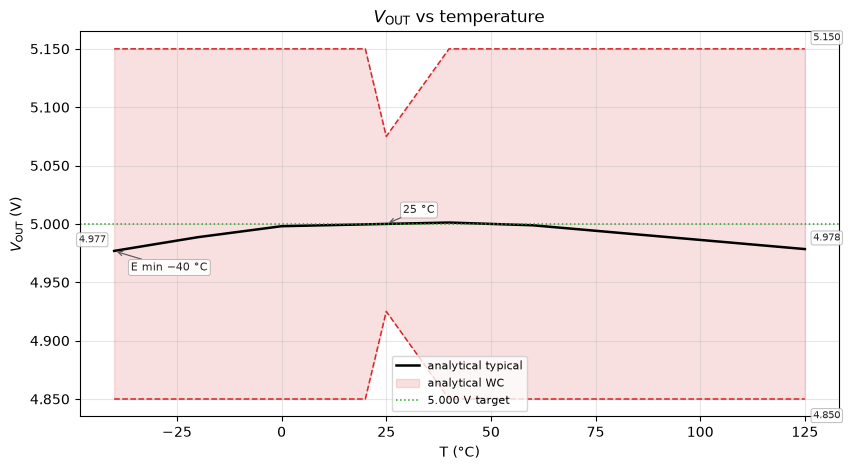

In [2]:
from p5v_design.temperature import sweep_analytical
sw = sweep_analytical(p)
sw.save(ROOT/"results"/"temp_analytical.csv")
display(sw.frame.head())
ann = [
    dict(text="25 °C", xy=(25, float(sw.frame.loc[sw.frame.temp_c==25, "vout"].iloc[0])),
         offset=(12, 10), arrow=True),
    dict(text="E min −40 °C", xy=(-40, float(sw.frame.iloc[0]["vout"])), offset=(12, -12), arrow=True),
]
plots.plot_temp_sweep(
    sw.frame.temp_c.to_numpy(), sw.frame.vout.to_numpy(),
    vout_lo=sw.frame.vout_wc_lo.to_numpy(), vout_hi=sw.frame.vout_wc_hi.to_numpy(),
    annotations=ann, path=FIG/"06_vout_vs_t.png",
)
plt.show()


## ngspice and LTspice WC vs temperature

Same ADJ-box switch as the analytical band (25 °C box only at 25 °C).

| Engine | Typical | WC |
|--------|---------|----|
| ngspice behavioral | OP on the **full** $T$ grid, G05 $V_{\mathrm{ADJ}}(T)$ | 16 corners at each $T$ |
| LTspice vendor lib | unbroken ADJ, macromodel $V_{\mathrm{ADJ}}(T)$ | 16 injected corners at **−40 / 25 / 125 °C** only |

LTspice WC is drawn as **error bars**, not a filled band, so three temperatures
do not invent a notch by interpolation. Set `SKIP_SPICE_WC_MC = True` to skip
ngspice; set `RUN_LTSPICE_BATCH = True` (or pre-run
`python LTSpice/run_ltspice_batch.py temp`) for vendor-lib logs.

The vendor macromodel is **typical-only** and is not guaranteed at MP cold.
Expect LTspice typical/WC at −55 °C to sit well below the datasheet envelope
(the lib’s ADJ voltage collapses); 25 °C and 125 °C should track analytical
with the same slight low bias already seen in notebook 05.


------------------------------------------------------------------------------


  ngspice WC hypercube


  ngspice  jobs=16  workers=8  requested=auto  cpu=8  env P5V_SPICE_WORKERS=''


  queue: R1lo_R2lo_Valo_Ialo, R1lo_R2lo_Valo_Iahi, R1lo_R2lo_Vahi_Ialo, R1lo_R2lo_Vahi_Iahi, R1lo_R2hi_Valo_Ialo, R1lo_R2hi_Valo_Iahi  +10 more


------------------------------------------------------------------------------


...

------------------------------------------------------------------------------


  [LTspice batch  6 deck(s)] done  6 ok / 0 fail / 6 jobs  workers=1  wall=5m52.1s  cpu=5m52.0s  speedup=1.00× vs serial


------------------------------------------------------------------------------


,temp_c,vout,engine
0,-40.0,4.97825,LTspice
1,25.0,4.97825,LTspice
2,125.0,4.97825,LTspice


,temp_c,engine,vout_lo,vout_hi,n_corners
0,-40.0,LTspice,4.9035,5.05301,2
1,25.0,LTspice,4.9035,5.05301,2
2,125.0,LTspice,4.9035,5.05301,2


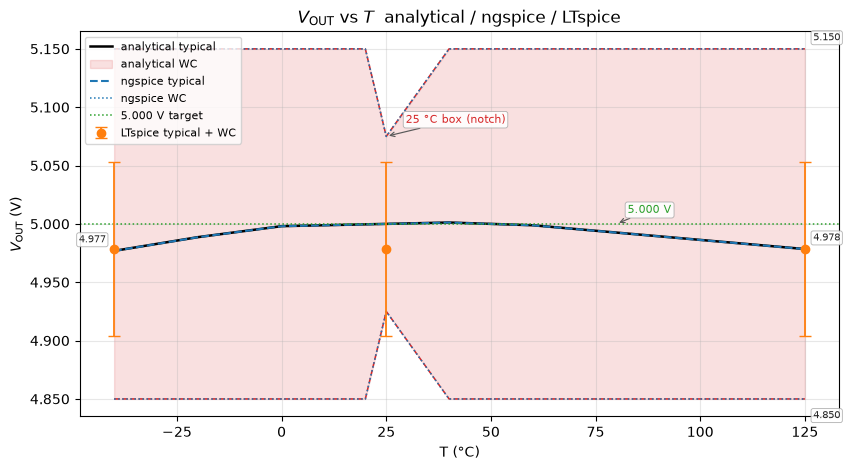

,T_C,an_nom,an_lo,an_hi,ng_nom,ng_lo,ng_hi,lt_nom,lt_lo,lt_hi,ng-an_mV
0,-40.0,4.976872,4.850,5.150,4.976822,4.849951,5.149948,4.97825,4.9035,5.05301,-0.049815
1,25.0,5.000000,4.925,5.075,4.999950,4.924951,5.074949,4.97825,4.9035,5.05301,-0.050000
2,125.0,4.978440,4.850,5.150,4.978390,4.849951,5.149948,4.97825,4.9035,5.05301,-0.049828


In [3]:
from p5v_design.temperature import (
    sweep_ngspice_nominal, sweep_ngspice_wc, sweep_ltspice_from_logs, temp_tag,
)
from p5v_design.simulate import find_ngspice

T_LTSPICE = [-40.0, 25.0, 125.0]
ng_nom = ng_wc = None
lt_nom = lt_wc = None

HAVE_SPICE = False
try:
    find_ngspice()
    HAVE_SPICE = True
except FileNotFoundError as e:
    print(e)

if HAVE_SPICE and not SKIP_SPICE_WC_MC:
    ng_nom = sweep_ngspice_nominal(
        p, workdir=ROOT/"results"/"ngspice_temp", root=ROOT,
    )
    ng_wc = sweep_ngspice_wc(
        p, workdir=ROOT/"results"/"ngspice_wc_temp", root=ROOT,
        max_workers=SPICE_WORKERS,
    )
    ng_nom.to_csv(ROOT/"results"/"temp_ngspice_nom.csv", index=False)
    ng_wc.to_csv(ROOT/"results"/"temp_ngspice_wc.csv", index=False)
    display(ng_wc)
else:
    print("ngspice temperature WC skipped")

import importlib.util
lt_py = ROOT / "LTSpice" / "run_ltspice_batch.py"
if lt_py.is_file():
    spec = importlib.util.spec_from_file_location("run_ltspice_batch", lt_py)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    mod.write_temp_decks(p, temps=T_LTSPICE)
else:
    print("LTspice helper is not in this repository. Vendor LT3010.lib is not redistributed.")
if RUN_LTSPICE_BATCH:
    from p5v_design.ltspice_io import find_ltspice, run_ltspice_decks
    try:
        find_ltspice()
        decks = []
        for T in T_LTSPICE:
            d = ROOT/"LTSpice"/"Temp"/temp_tag(T)
            decks += [d/"P5V_ISO_Regulator_op.cir", d/"P5V_ISO_Regulator_WC.cir"]
        run_ltspice_decks(decks, max_workers=LTSPICE_WORKERS)
    except FileNotFoundError as e:
        print(e)
else:
    print("LTspice temp batch skipped (RUN_LTSPICE_BATCH=False). Existing logs still parsed.")

lt_nom, lt_wc = sweep_ltspice_from_logs(p, temp_root=ROOT/"LTSpice"/"Temp", temps=T_LTSPICE)
display(lt_nom)
display(lt_wc)

kw = dict(
    vout_lo=sw.frame.vout_wc_lo.to_numpy(), vout_hi=sw.frame.vout_wc_hi.to_numpy(),
)
if ng_nom is not None:
    kw["ng_temps"] = ng_nom.temp_c.to_numpy()
    kw["ng_vout"] = ng_nom.vout.to_numpy()
if ng_wc is not None:
    kw["ng_lo"] = ng_wc.vout_lo.to_numpy()
    kw["ng_hi"] = ng_wc.vout_hi.to_numpy()
if lt_nom is not None and lt_nom.vout.notna().any():
    kw["lt_temps"] = lt_nom.temp_c.to_numpy()
    kw["lt_vout"] = lt_nom.vout.to_numpy()
if lt_wc is not None and lt_wc.vout_lo.notna().any():
    kw["lt_lo"] = lt_wc.vout_lo.to_numpy()
    kw["lt_hi"] = lt_wc.vout_hi.to_numpy()
ann_ov = [
    dict(text="25 °C box (notch)", xy=(25.0, float(sw.frame.loc[np.isclose(sw.frame.temp_c, 25), "vout_wc_hi"].iloc[0])),
         offset=(14, 12), arrow=True, color="C3"),
    dict(text="5.000 V", xy=(80.0, 5.0), offset=(8, 10), arrow=True, color="#2ca02c"),
]
plots.plot_temp_sweep(
    sw.frame.temp_c.to_numpy(), sw.frame.vout.to_numpy(),
    annotations=ann_ov, path=FIG/"06_vout_vs_t_engines.png",
    title=r"$V_{\mathrm{OUT}}$ vs $T$  analytical / ngspice / LTspice",
    **kw,
)
plt.show()

# Three-temperature comparison table
rows = []
for T in T_LTSPICE:
    an = sw.frame.loc[np.isclose(sw.frame.temp_c, T)].iloc[0]
    rec = {"T_C": T, "an_nom": an.vout, "an_lo": an.vout_wc_lo, "an_hi": an.vout_wc_hi}
    if ng_nom is not None:
        rec["ng_nom"] = float(ng_nom.loc[np.isclose(ng_nom.temp_c, T), "vout"].iloc[0])
    if ng_wc is not None:
        rec["ng_lo"] = float(ng_wc.loc[np.isclose(ng_wc.temp_c, T), "vout_lo"].iloc[0])
        rec["ng_hi"] = float(ng_wc.loc[np.isclose(ng_wc.temp_c, T), "vout_hi"].iloc[0])
    if lt_nom is not None and lt_nom.vout.notna().any():
        rec["lt_nom"] = float(lt_nom.loc[np.isclose(lt_nom.temp_c, T), "vout"].iloc[0])
    if lt_wc is not None and lt_wc.vout_lo.notna().any():
        rec["lt_lo"] = float(lt_wc.loc[np.isclose(lt_wc.temp_c, T), "vout_lo"].iloc[0])
        rec["lt_hi"] = float(lt_wc.loc[np.isclose(lt_wc.temp_c, T), "vout_hi"].iloc[0])
    rows.append(rec)
cmp = pd.DataFrame(rows)
if "ng_nom" in cmp.columns:
    cmp["ng-an_mV"] = 1e3 * (cmp["ng_nom"] - cmp["an_nom"])
display(cmp)


## Dropout, $I_{\mathrm{GND}}$, dissipation, $T_j$, PSRR vs $T$

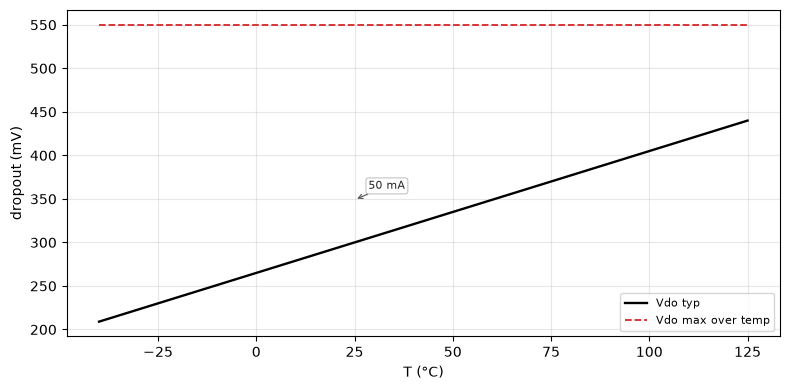

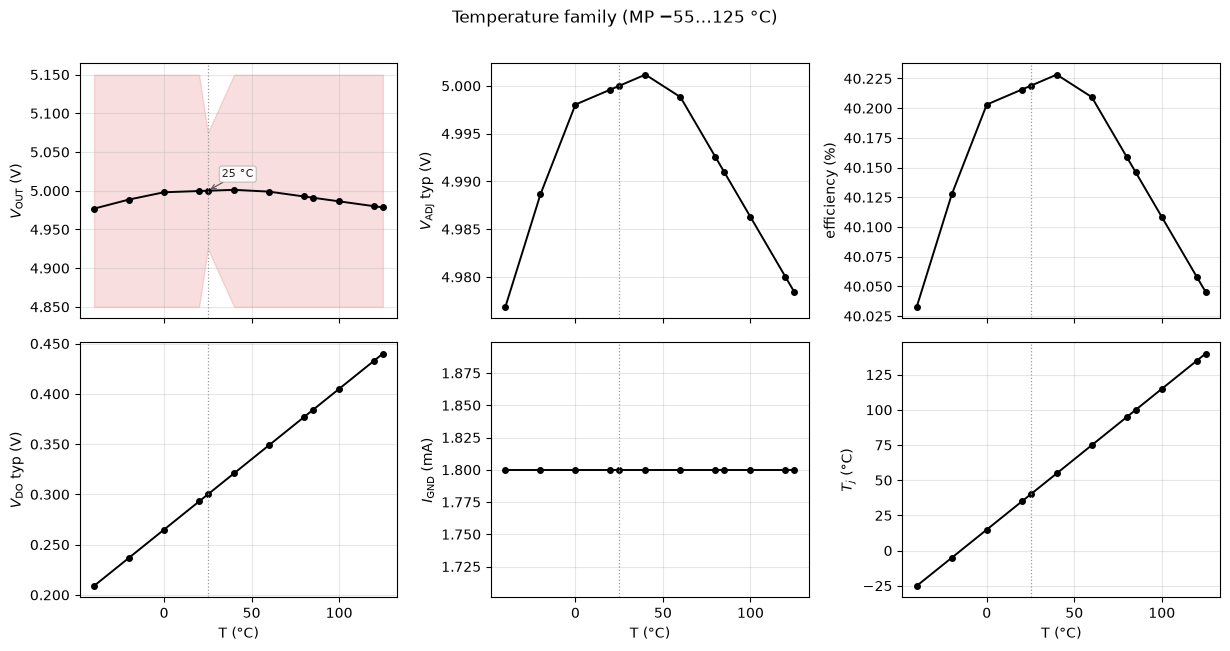

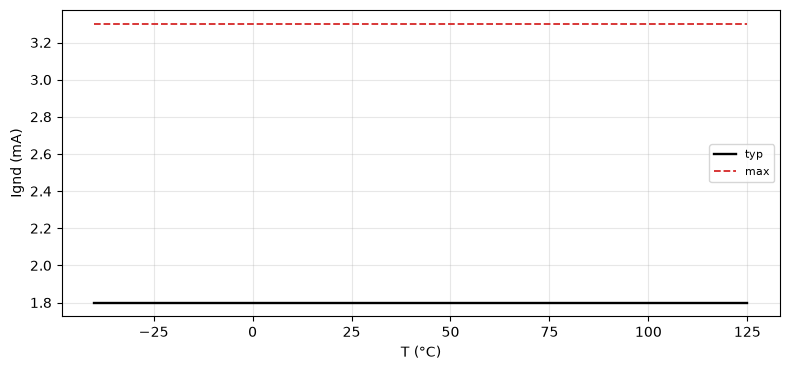

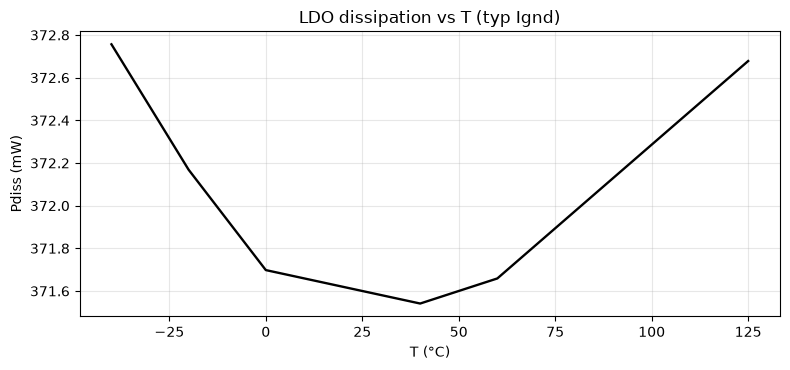

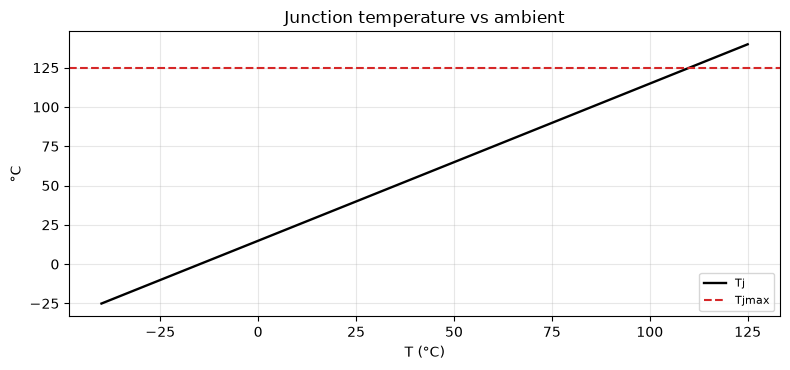

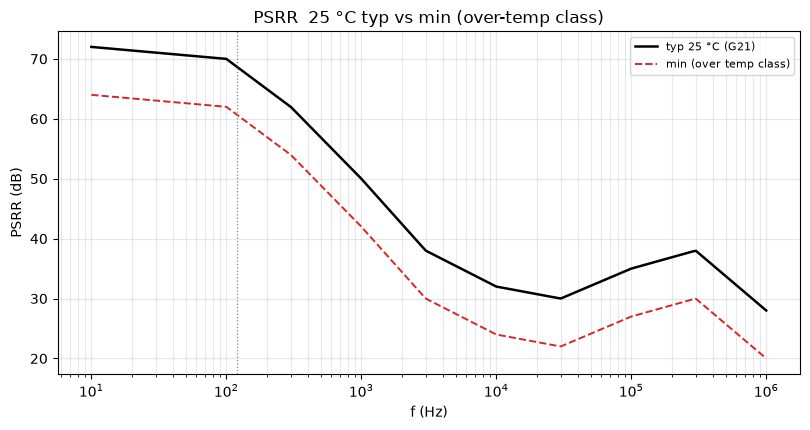

In [4]:
fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.plot(sw.frame.temp_c, 1e3*sw.frame.vdo_typ, "k-", lw=1.7, label="Vdo typ")
ax.plot(sw.frame.temp_c, 1e3*sw.frame.vdo_wc, "C3--", lw=1.3, label="Vdo max over temp")
ax.set_xlabel("T (°C)")
ax.set_ylabel("dropout (mV)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plots.apply_annotations(ax, [dict(text="50 mA", xy=(25, 1e3*sw.frame.vdo_typ.iloc[len(sw.frame)//2]), offset=(10, 10), arrow=True)])
plots.savefig(fig, FIG/"06_vdo_vs_t.png")
plt.show()
ann_g = [dict(text="25 °C", xy=(25, float(sw.frame.loc[np.isclose(sw.frame.temp_c, 25), "vout"].iloc[0])), offset=(10, 12), arrow=True)]
plots.plot_temp_grid(sw.frame, annotations=ann_g, path=FIG/"06_temp_grid.png")
plt.show()
fig, ax = plt.subplots(figsize=(8.0, 3.8))
ax.plot(sw.frame.temp_c, 1e3*sw.frame.ignd_typ, "k-", lw=1.7, label="typ")
ax.plot(sw.frame.temp_c, 1e3*sw.frame.ignd_max, "C3--", lw=1.3, label="max")
ax.set_xlabel("T (°C)"); ax.set_ylabel("Ignd (mA)"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plots.savefig(fig, FIG/"06_ignd_vs_t.png"); plt.show()
fig, ax = plt.subplots(figsize=(8.0, 3.8))
ax.plot(sw.frame.temp_c, 1e3*sw.frame.p_diss, "k-", lw=1.7)
ax.set_xlabel("T (°C)"); ax.set_ylabel("Pdiss (mW)")
ax.set_title("LDO dissipation vs T (typ Ignd)")
ax.grid(True, alpha=0.3)
plots.savefig(fig, FIG/"06_pdiss_vs_t.png"); plt.show()
fig, ax = plt.subplots(figsize=(8.0, 3.8))
ax.plot(sw.frame.temp_c, sw.frame.tj_c, "k-", lw=1.7, label="Tj")
ax.axhline(p.ldo.tj_max_c, color="C3", ls="--", label="Tjmax")
ax.set_xlabel("T (°C)"); ax.set_ylabel("°C"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_title("Junction temperature vs ambient")
plots.savefig(fig, FIG/"06_tj_vs_t.png"); plt.show()
# PSRR min over-temp is datasheet typ−10 dB (page 3)
f = np.logspace(1, 6, 241)
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.semilogx(f, psrr_db(f, cout=p.cout), "k-", lw=1.8, label="typ 25 °C (G21)")
ax.semilogx(f, psrr_db(f, cout=p.cout, typ=False), "C3--", lw=1.4, label="min (over temp class)")
ax.axvline(120, color="0.5", ls=":", lw=0.9)
ax.set_xlabel("f (Hz)"); ax.set_ylabel("PSRR (dB)")
ax.set_title("PSRR  25 °C typ vs min (over-temp class)")
ax.legend(fontsize=8); ax.grid(True, which="both", alpha=0.3)
plots.savefig(fig, FIG/"06_psrr_vs_t.png"); plt.show()